In [8]:
question_answering_project/
│
├── data/
│   └── chennamma_passage.txt
├── word2vec_model/
│   └── word2vec.model
├── main.py
├── requirements.txt
└── README.md


SyntaxError: invalid character '│' (U+2502) (ipython-input-8-3701915620.py, line 2)

# Passage (Context Text)
Rani Chennamma of Kittur (1778–1829) was one of the earliest Indian female freedom fighters. She is celebrated for leading an armed rebellion against the British East India Company in 1824 in response to the Doctrine of Lapse. Born in Kakati, a small village in present-day Karnataka, she was trained in horse riding, sword fighting, and archery from a young age. She married Mallasarja Desai, the ruler of Kittur, and became the queen. After her husband's death and the loss of her only son, she adopted a boy to continue the royal line. However, the British East India Company refused to recognize the adoption, aiming to annex Kittur under the Doctrine of Lapse.

In October 1824, when British forces, led by St John Thackeray, attempted to seize the kingdom, Rani Chennamma resisted. With the help of her trusted generals like Sangolli Rayanna and Gurusiddappa, she led her troops bravely into battle. In the first confrontation, the British suffered heavy losses, and Thackeray was killed. However, the British returned with reinforcements and eventually captured Chennamma. She was imprisoned in Bailhongal Fort, where she died in 1829.

Despite her defeat, Rani Chennamma's bravery became a symbol of resistance and inspiration for later freedom fighters. Her defiance occurred decades before the 1857 revolt and laid the foundation for the Indian independence movement. Today, she is remembered as a heroine in Karnataka, and her legacy is honored with statues, folk songs, and school textbooks. Her story is a testament to the courage and strength of Indian women who fought against colonialism.

Rani Chennamma was not only a warrior but also a skilled administrator. She implemented reforms for the welfare of her subjects and supported local artisans and farmers. Her court encouraged traditional arts and Sanskrit learning. Her leadership style was progressive, promoting gender equality and justice. She believed in dharma (righteous duty) and governed with compassion and fairness.

Her close advisor, Sangolli Rayanna, continued the rebellion even after her death. Rayanna formed a guerilla army and fought against British rule until he too was captured and hanged in 1831. The sacrifices made by Chennamma and Rayanna have become folklore in Karnataka and are retold in poems and plays.

# Text Preprocessing (Using NLTK)


Sentence tokenization

Word tokenization

Lowercasing

Stop word removal

Lemmatization

In [2]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

text = """Rani Chennamma of Kittur (1778–1829) was one of the earliest Indian female freedom fighters. She is celebrated for leading an armed rebellion against the British East India Company in 1824 in response to the Doctrine of Lapse. Born in Kakati, a small village in present-day Karnataka, she was trained in horse riding, sword fighting, and archery from a young age. She married Mallasarja Desai, the ruler of Kittur, and became the queen. After her husband's death and the loss of her only son, she adopted a boy to continue the royal line. However, the British East India Company refused to recognize the adoption, aiming to annex Kittur under the Doctrine of Lapse.

In October 1824, when British forces, led by St John Thackeray, attempted to seize the kingdom, Rani Chennamma resisted. With the help of her trusted generals like Sangolli Rayanna and Gurusiddappa, she led her troops bravely into battle. In the first confrontation, the British suffered heavy losses, and Thackeray was killed. However, the British returned with reinforcements and eventually captured Chennamma. She was imprisoned in Bailhongal Fort, where she died in 1829.

Despite her defeat, Rani Chennamma's bravery became a symbol of resistance and inspiration for later freedom fighters. Her defiance occurred decades before the 1857 revolt and laid the foundation for the Indian independence movement. Today, she is remembered as a heroine in Karnataka, and her legacy is honored with statues, folk songs, and school textbooks. Her story is a testament to the courage and strength of Indian women who fought against colonialism.

Rani Chennamma was not only a warrior but also a skilled administrator. She implemented reforms for the welfare of her subjects and supported local artisans and farmers. Her court encouraged traditional arts and Sanskrit learning. Her leadership style was progressive, promoting gender equality and justice. She believed in dharma (righteous duty) and governed with compassion and fairness.

Her close advisor, Sangolli Rayanna, continued the rebellion even after her death. Rayanna formed a guerilla army and fought against British rule until he too was captured and hanged in 1831. The sacrifices made by Chennamma and Rayanna have become folklore in Karnataka and are retold in poems and plays."""

# Sentence & word tokenization
sentences = sent_tokenize(text)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(sentence):
    words = word_tokenize(sentence.lower())
    words = [w for w in words if w not in stop_words and w not in string.punctuation]
    words = [lemmatizer.lemmatize(w) for w in words]
    return words

processed_sentences = [preprocess(sent) for sent in sentences]


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Word2Vec Embeddings

In [5]:
pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 486.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 12.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.0
    Uninstalling scipy-1.16.0:
      Successfully uninstalled scipy-1.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tsfr

In [3]:
from gensim.models import Word2Vec

# Train Word2Vec model
model = Word2Vec(sentences=processed_sentences, vector_size=100, window=5, min_count=1, workers=4)

# Get vector for a word
vector = model.wv['chennamma']



 1. sentences
Type: List of lists (tokenized sentences)

Purpose: These are the input sentences used to train the Word2Vec model.

Example:

sentences = [["rani", "chennamma", "was", "queen"], ["she", "fought", "british"]]
 This is required.

 2. vector_size
Type: int

Purpose: Dimensionality of the word vectors.

Default: 100

Common Values: 50, 100, 200, 300

Higher values capture more semantic meaning but require more data and computation.

 3. window
Type: int

Purpose: Maximum distance between the current and predicted word within a sentence.

Default: 5

 A smaller window focuses on local context, a larger one captures broader context.

Example:
Sentence = "Rani Chennamma fought the British bravely"
If window=2, for the word "fought", context = ["Chennamma", "the"]

 4. min_count
Type: int

Purpose: Ignores all words with total frequency lower than this.

Default: 5

Use min_count=1 for small datasets (like a single passage), so rare words aren't ignored.

 5. workers
Type: int

Purpose: Number of CPU threads used for training (for parallelization).

Default: 1

Use higher values like 4 or 8 for faster training on multi-core machines.



 # Prepare Dataset for QA

In [4]:
qa_pairs = [
    ("Who was Rani Chennamma?", "Rani Chennamma was the queen of Kittur and a freedom fighter."),
    ("What did she fight against?", "She fought against the British East India Company."),
    ("Who led British forces against her?", "St John Thackeray led the British forces."),
    ("When did she die?", "She died in 1829."),
    ("Who continued the fight after her?", "Sangolli Rayanna continued the fight.")
]


# Build the LSTM Model

In [5]:
import numpy as np
from keras.preprocessing.sequence import pad_sequences

# Create question & answer vectors
def sentence_to_vector(sentence, model):
    words = preprocess(sentence)
    vectors = [model.wv[word] for word in words if word in model.wv]
    return vectors

X = [sentence_to_vector(q, model) for q, a in qa_pairs]
y = [sentence_to_vector(a, model) for q, a in qa_pairs]

# Padding to uniform length
max_len = max(max(len(x) for x in X), max(len(a) for a in y))
X_pad = pad_sequences([np.array(x) for x in X], maxlen=max_len, dtype='float32', padding='post')
y_pad = pad_sequences([np.array(a) for a in y], maxlen=max_len, dtype='float32', padding='post')


# Define and Train LSTM

In [27]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, TimeDistributed, RepeatVector, Masking

model_lstm = Sequential()
model_lstm.add(Masking(mask_value=0., input_shape=(max_len, 100)))
model_lstm.add(LSTM(128))
model_lstm.add(RepeatVector(max_len))
model_lstm.add(LSTM(128, return_sequences=True))
model_lstm.add(TimeDistributed(Dense(100)))

model_lstm.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
history = model_lstm.fit(X_pad, y_pad, epochs=100, verbose=1)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 2.4495e-05 - mae: 0.0037
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.3886e-05 - mae: 0.0039
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 2.3838e-05 - mae: 0.0039
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.3723e-05 - mae: 0.0039
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 2.3459e-05 - mae: 0.0038
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 2.3251e-05 - mae: 0.0038
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 2.3144e-05 - mae: 0.0037
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.3071e-05 - mae: 0.0037
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 2.2996e-05 - mae: 0.0037
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.2910e-05 - mae: 0.0037
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.2815e-05 - mae: 0.0037
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 2.2732e-05 - mae: 0.0037
Epo

# Inference

In [24]:
def answer_question(question):
    vec = sentence_to_vector(question, model)
    padded_vec = pad_sequences([np.array(vec)], maxlen=max_len, dtype='float32', padding='post')
    pred = model_lstm.predict(padded_vec)

    # Find closest words from embeddings
    answer = ""
    for word_vec in pred[0]:
        try:
            sim_word = model.wv.similar_by_vector(word_vec, topn=1)[0][0]
            answer += sim_word + " "
        except:
            continue
    return answer

print(answer_question("Who fought the British after Chennamma?"))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step
died british british british force force 


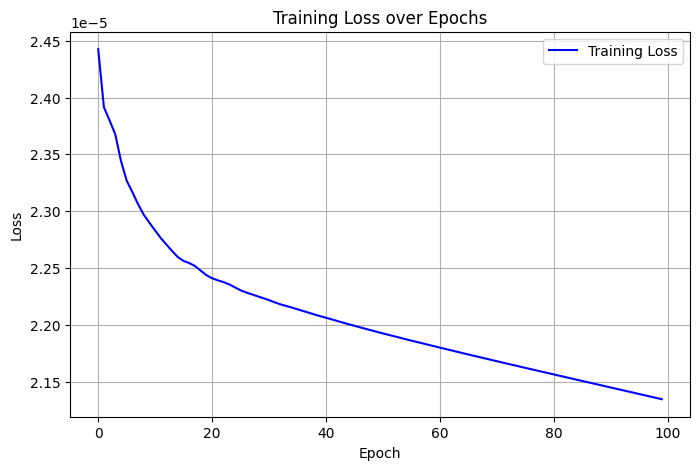

In [25]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


KeyError: 'accuracy'

<Figure size 800x500 with 0 Axes>